In [2]:
import pandas as pd
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load filtered tweets
tweets = pd.read_csv('../data/processed/tweets_filtered.csv')
tweets['date'] = pd.to_datetime(tweets['date'])

print(f"Loaded {len(tweets)} tweets")
tweets[['date', 'text']].head()

Loaded 3417 tweets


,date,text
0,2020-09-12 20:10:58,The Unsolicited Mail In Ballot Scam is a major...
1,2020-10-12 22:22:39,"“I’m running as a proud Democrat, for the Sena..."
2,2021-01-04 15:23:50,“We are not acting to thwart the Democratic pr...
3,2020-10-16 11:15:55,RT @RandPaul: Somebody is mad that @realDonald...
4,2020-10-16 11:01:28,"RT @RandPaul: In his term, @realDonaldTrump ha..."


In [4]:
# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Score each tweet
def get_sentiment(text):
    scores = analyzer.polarity_scores(str(text))
    return scores['compound']

tweets['sentiment'] = tweets['text'].apply(get_sentiment)

print(f"Sentiment scored for {len(tweets)} tweets")
print(f"\nSentiment distribution:")
print(f"Positive (>0.05):  {(tweets['sentiment'] > 0.05).sum()}")
print(f"Neutral:           {((tweets['sentiment'] >= -0.05) & (tweets['sentiment'] <= 0.05)).sum()}")
print(f"Negative (<-0.05): {(tweets['sentiment'] < -0.05).sum()}")
tweets[['date', 'text', 'sentiment']].head(10)

Sentiment scored for 3417 tweets

Sentiment distribution:
Positive (>0.05):  1931
Neutral:           354
Negative (<-0.05): 1132


,date,text,sentiment
0,2020-09-12 20:10:58,The Unsolicited Mail In Ballot Scam is a major...,-0.9571
1,2020-10-12 22:22:39,"“I’m running as a proud Democrat, for the Sena...",0.0000
2,2021-01-04 15:23:50,“We are not acting to thwart the Democratic pr...,0.3818
3,2020-10-16 11:15:55,RT @RandPaul: Somebody is mad that @realDonald...,-0.7906
4,2020-10-16 11:01:28,"RT @RandPaul: In his term, @realDonaldTrump ha...",0.5267
5,2020-11-16 13:27:55,RT @realDonaldTrump: ANTIFA SCUM ran for the h...,-0.4588
6,2021-01-05 14:50:49,Pleased to announce that @KLoeffler &amp; @sen...,-0.5707
7,2020-11-16 14:19:29,Another Vaccine just announced. This time by M...,0.9312
8,2021-01-05 15:02:22,"Georgia, get out and VOTE for two great Senato...",0.7756
9,2021-01-05 22:25:08,"Antifa is a Terrorist Organization, stay out o...",-0.7177


In [5]:
# Extract date only (no time)
tweets['date_only'] = tweets['date'].dt.date

# Aggregate daily sentiment
daily_sentiment = tweets.groupby('date_only').agg(
    sentiment_mean=('sentiment', 'mean'),
    sentiment_min=('sentiment', 'min'),
    sentiment_max=('sentiment', 'max'),
    tweet_count=('sentiment', 'count')
).reset_index()

daily_sentiment['date_only'] = pd.to_datetime(daily_sentiment['date_only'])
daily_sentiment = daily_sentiment.sort_values('date_only')

print(f"Trading days with defense tweets: {len(daily_sentiment)}")
print(f"\nSentiment stats:")
print(daily_sentiment['sentiment_mean'].describe())

Trading days with defense tweets: 1062

Sentiment stats:
count    1062.000000
mean        0.187944
std         0.491840
min        -0.980000
25%        -0.112204
50%         0.222027
75%         0.597100
max         0.976100
Name: sentiment_mean, dtype: float64


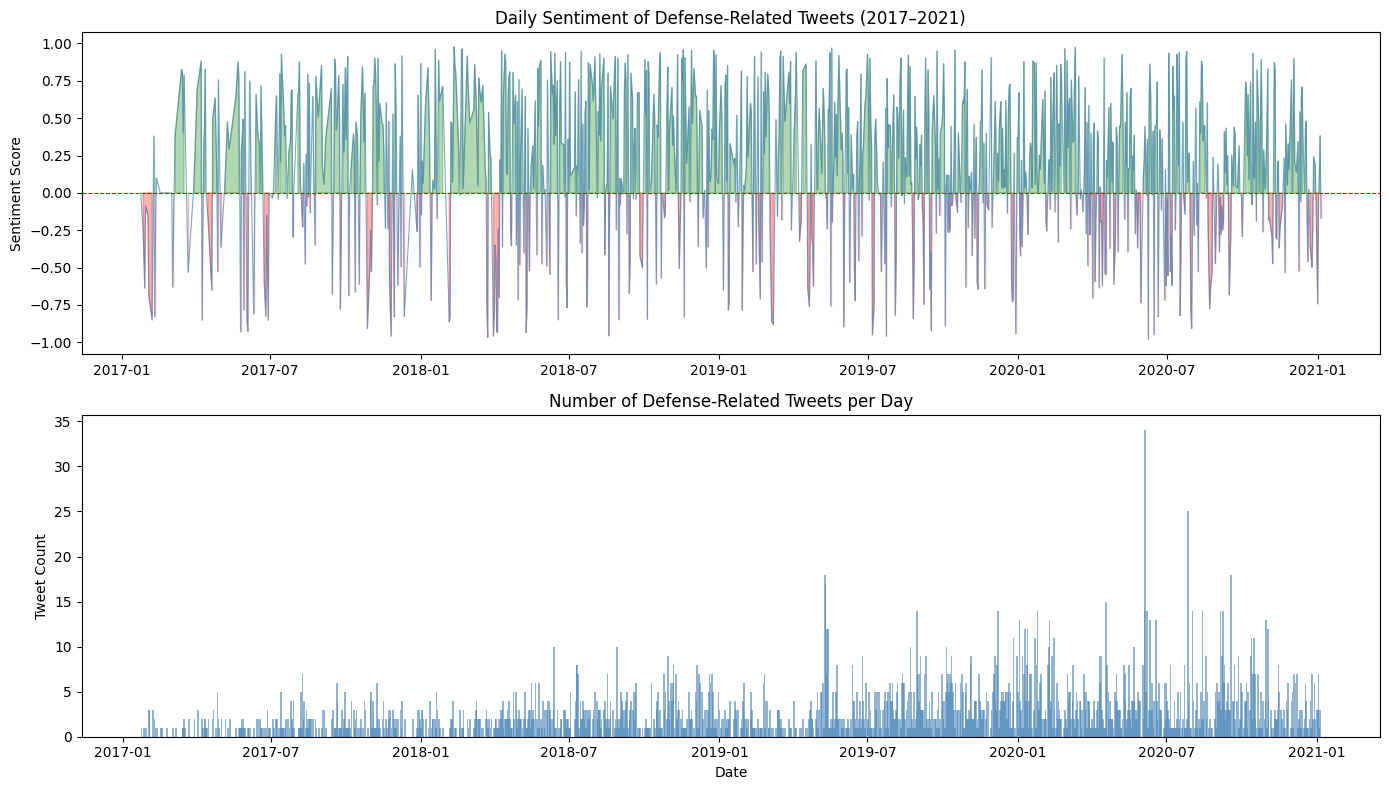

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Sentiment over time
axes[0].plot(daily_sentiment['date_only'], daily_sentiment['sentiment_mean'], 
             color='steelblue', linewidth=0.8, alpha=0.7)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=0.8)
axes[0].fill_between(daily_sentiment['date_only'], daily_sentiment['sentiment_mean'], 0,
                     where=daily_sentiment['sentiment_mean'] > 0, alpha=0.3, color='green')
axes[0].fill_between(daily_sentiment['date_only'], daily_sentiment['sentiment_mean'], 0,
                     where=daily_sentiment['sentiment_mean'] < 0, alpha=0.3, color='red')
axes[0].set_title('Daily Sentiment of Defense-Related Tweets (2017–2021)')
axes[0].set_ylabel('Sentiment Score')

# Tweet volume over time
axes[1].bar(daily_sentiment['date_only'], daily_sentiment['tweet_count'],
            color='steelblue', alpha=0.6, width=2)
axes[1].set_title('Number of Defense-Related Tweets per Day')
axes[1].set_ylabel('Tweet Count')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('../outputs/figures/sentiment_over_time.png', dpi=150)
plt.show()

In [7]:
# Save daily sentiment for next notebook
daily_sentiment.to_csv('../data/processed/daily_sentiment.csv', index=False)
print("Daily sentiment saved.")
print(f"Shape: {daily_sentiment.shape}")

Daily sentiment saved.
Shape: (1062, 5)


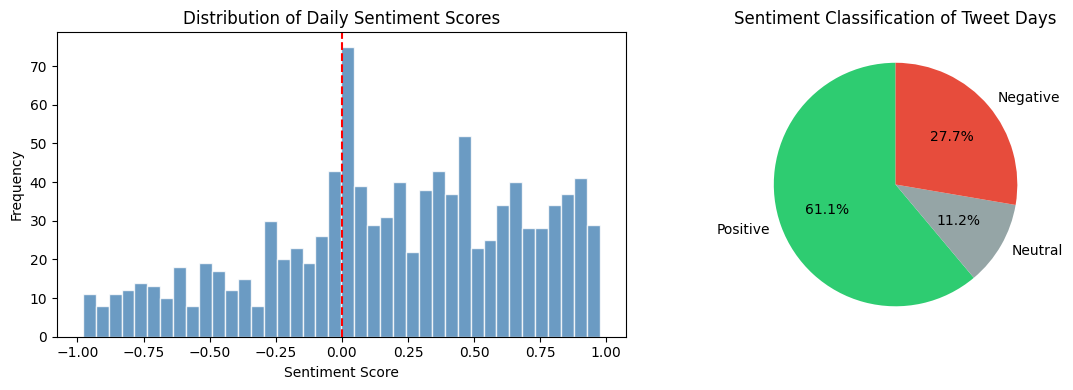

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(daily_sentiment['sentiment_mean'], bins=40, 
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_title('Distribution of Daily Sentiment Scores')
axes[0].set_xlabel('Sentiment Score')
axes[0].set_ylabel('Frequency')

# Classify days
conditions = [
    daily_sentiment['sentiment_mean'] > 0.05,
    daily_sentiment['sentiment_mean'] < -0.05
]
labels = ['Positive', 'Negative']
counts = [cond.sum() for cond in conditions]
neutral = len(daily_sentiment) - sum(counts)

axes[1].pie(
    [counts[0], neutral, counts[1]],
    labels=['Positive', 'Neutral', 'Negative'],
    colors=['#2ecc71', '#95a5a6', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Sentiment Classification of Tweet Days')

plt.tight_layout()
plt.savefig('../outputs/figures/sentiment_distribution.png', dpi=150)
plt.show()